<a href="https://colab.research.google.com/github/BhagyashreeMohalkar/ADS_Lab_Assignments/blob/main/CNN_based_Handwritten_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Import libraries and check GPU

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cell 2: Load MNIST handwritten digit dataset

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images :", x_train.shape)
print("Training labels :", y_train.shape)
print("Testing images  :", x_test.shape)
print("Testing labels  :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images : (60000, 28, 28)
Training labels : (60000,)
Testing images  : (10000, 28, 28)
Testing labels  : (10000,)


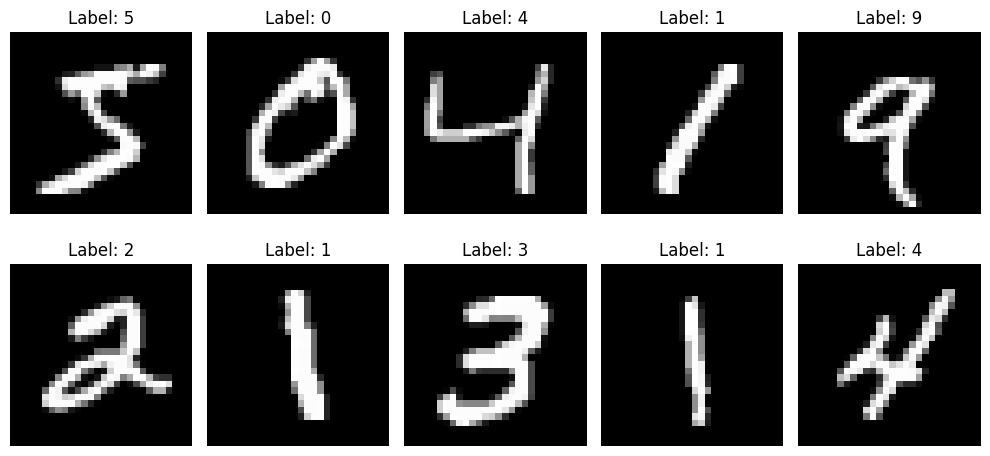

In [3]:
# Cell 3: Visualize sample handwritten digits

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Digit Distribution:
Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images


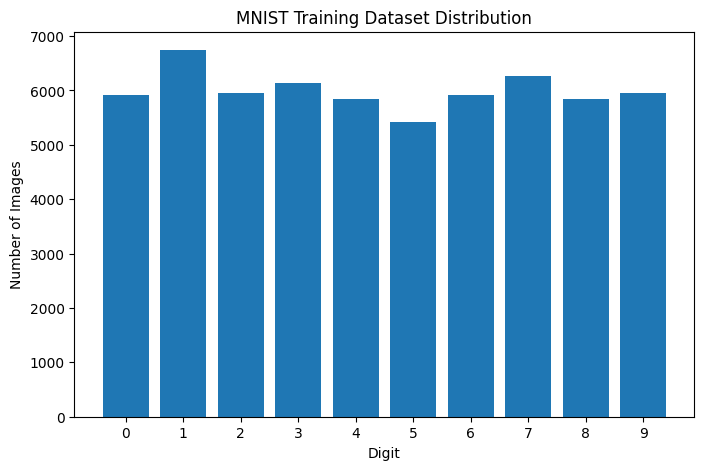

In [4]:
# Cell 4: Check class distribution

unique, counts = np.unique(y_train, return_counts=True)

print("Digit Distribution:")
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images")

# Plot distribution
plt.figure(figsize=(8, 5))
plt.bar(unique, counts)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("MNIST Training Dataset Distribution")
plt.xticks(unique)

plt.show()

In [5]:
# Cell 5: Preprocessing

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training data shape:", x_train.shape)
print("Testing data shape :", x_test.shape)
print("Pixel value range  :", x_train.min(), "to", x_train.max())

Training data shape: (60000, 28, 28, 1)
Testing data shape : (10000, 28, 28, 1)
Pixel value range  : 0.0 to 1.0


In [6]:
# Cell 6: Build CNN model

model = Sequential([

    # Convolutional Layer 1
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),
    MaxPooling2D((2, 2)),

    # Convolutional Layer 2
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    MaxPooling2D((2, 2)),

    # Convert feature maps into 1D
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation="relu"),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output layer: 10 digits
    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Cell 7: Compile CNN model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [8]:
# Cell 8: Train CNN model using GPU

EPOCHS = 10
BATCH_SIZE = 128

with tf.device("/GPU:0"):
    history = model.fit(
        x_train,
        y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.1,
        verbose=1
    )

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9048 - loss: 0.3099 - val_accuracy: 0.9833 - val_loss: 0.0599
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9720 - loss: 0.0974 - val_accuracy: 0.9852 - val_loss: 0.0449
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9790 - loss: 0.0688 - val_accuracy: 0.9873 - val_loss: 0.0415
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9826 - loss: 0.0585 - val_accuracy: 0.9908 - val_loss: 0.0327
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9854 - loss: 0.0480 - val_accuracy: 0.9915 - val_loss: 0.0300
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9878 - loss: 0.0406 - val_accuracy: 0.9905 - val_loss: 0.0340
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9887 - loss: 0.0364 - val_accuracy: 0.9912 - val_loss: 0.0320
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9903 - loss: 0.0311 - val_accuracy: 

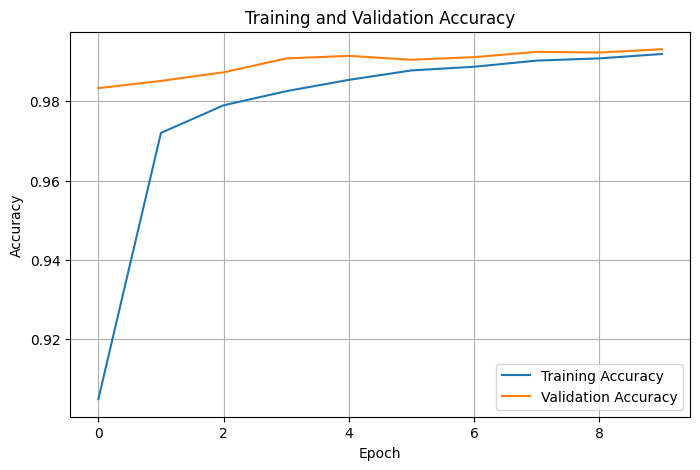

In [9]:
# Cell 9: Plot accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

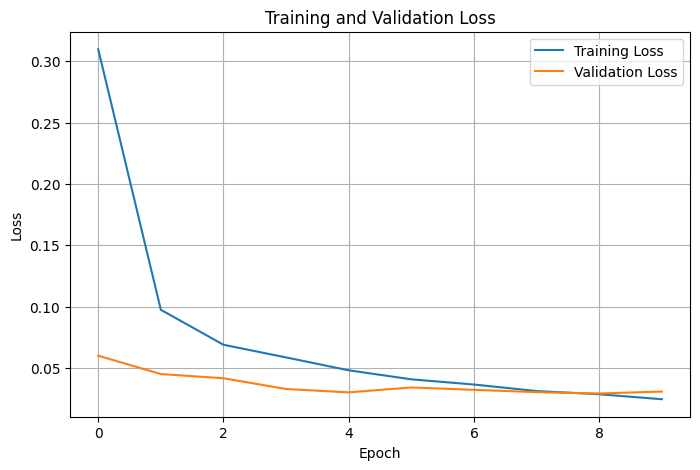

In [10]:
# Cell 10: Plot loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
# Cell 11: Evaluate CNN on test dataset

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("\nTest Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9924 - loss: 0.0236

Test Loss     : 0.0236
Test Accuracy : 99.24 %


In [12]:
# Cell 12: Generate predictions

y_prob = model.predict(x_test, verbose=1)

# Convert probabilities to predicted digit
y_pred = np.argmax(y_prob, axis=1)

print("Predictions generated successfully!")

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nPerformance Metrics")
print("-------------------")
print("Accuracy :", round(accuracy, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Predictions generated successfully!

Performance Metrics
-------------------
Accuracy : 0.9924


In [13]:
# Cell 13: Classification report

print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[str(i) for i in range(10)]
    )
)

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



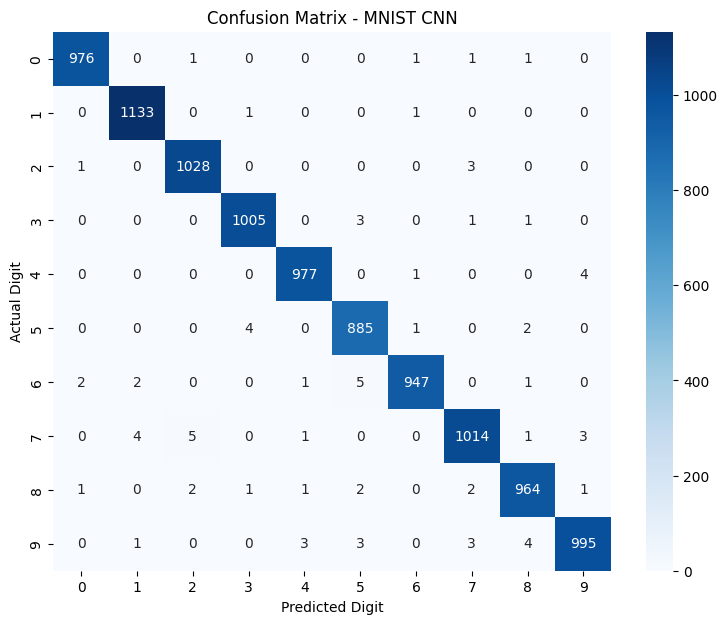

In [14]:
# Cell 14: Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("Confusion Matrix - MNIST CNN")

plt.show()